# Lista de Exercício 2
### Visão Computacional (SEL0339/SEL5886)

**Instruções:**

 1. Esta lista consiste em 6 exercícios.
 1. Deve-se colocar comentários nos códigos desenvolvidos.
 1. As perguntas devem ser respondidas também como comentários no arquivo.
 1. Colocar seu nome e número USP abaixo.
 1. Quaisquer problemas na execução das listas, entrar em contato com os monitores.
 1. Depois de terminados os exercícios, deve ser gerado um arquivo **extensão .ipynb** para ser enviado ao professor pelo E-DISCIPLINAS da disciplina até a data máxima de entrega.
 1. Caso não seja enviado - ou identifique-se cópia - o aluno ficará sem nota.


---



 <table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/LAVI-Disciplinas/SEL0339-SEL5886_2026/blob/main/praticas/Lista_de_Exercicio_2.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Executar no Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/blob/main/praticas/Lista_de_Exercicio_2.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />Ver codigo fonte no GitHub</a>
  </td>
</table>


`Nome: Mateus de Paula Souza `

`Número USP: 17932172 `

### Introdução:

Esta lista de exercícios abordará o tema de operações morfológicas. "As transformações morfológicas são algumas operações simples baseadas na forma da imagem. Normalmente são executadas em imagens binárias. Elas precisam de duas entradas: a nossa imagem original e o chamado elemento estruturante (SE) ou *kernel*, que decide a natureza da operação. Dois operadores morfológicos básicos são **Erosão** e **Dilatação**. Em seguida, suas formas variantes como **Abertura**, **Fechamento** também entram em jogo." [1]


<center><img src="https://docs.opencv.org/4.1.0/Morphology_1_Tutorial_Theory_Original_Image.png" style="float: left; width: 30%; margin-right: 1%; margin-bottom: 0.5em;"><img src="https://docs.opencv.org/4.1.0/Morphology_1_Tutorial_Theory_Erosion.png" style="float: left; width: 30%; margin-right: 1%; margin-bottom: 0.5em;"><img src="https://docs.opencv.org/4.1.0/Morphology_1_Tutorial_Theory_Dilation.png" style="float: left; width: 30%; margin-right: 1%; margin-bottom: 0.5em;"></center>
<center><caption><b> Figura 1: </b> Da esquerda para a direita: original, erosão e dilatação.</b></caption></center>
<caption><center> Referência: OpenCV - <a href="https://docs.opencv.org/3.4.8/d9/d61/tutorial_py_morphological_ops.html">Morphological Transformations</a>.</center></caption>


Referências:

*   Material da sala de aula;
*   Gonzalez and Woods, Digital Image Processing 4th;
*   [1] OpenCV: [Morphological Transformations](https://docs.opencv.org/3.4.8/d9/d61/tutorial_py_morphological_ops.html);

Vamos importar as bibliotecas que iremos utilizar:

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

#### **Atenção**: os códigos abaixo são para fazer o download das imagens (EXECUTE-OS). Os mesmos não fazem parte dessa prática.

In [2]:
import urllib.request

try:
  urllib.request.urlretrieve("https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/A.png", "A.png")
except:
  print("[ERRO] Não foi possível fazer o download da imagem A.png dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/B.png", "B.png")
except:
  print("[ERRO] Não foi possível fazer o download da imagem B.png dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/coins.jpg", "coins.jpg")
except:
  print("[ERRO] Não foi possível fazer o download da imagem coins.jpg dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/shapes.png", "shapes.png")
except:
  print("[ERRO] Não foi possível fazer o download da imagem shapes.png dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/shapes_resultado.png", "shapes_resultado.png")
except:
  print("[ERRO] Não foi possível fazer o download da imagem shapes_resultado.png dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/texto.png", "texto.png")
except:
  print("[ERRO] Não foi possível fazer o download da imagem texto.png dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/elefante.tif", "elefante.tif")
except:
  print("[ERRO] Não foi possível fazer o download da imagem elefante.tif dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/card1.jpg", "card1.jpg")
except:
  print("[ERRO] Não foi possível fazer o download da imagem card1.jp dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/card2.png", "card2.png")
except:
  print("[ERRO] Não foi possível fazer o download da imagem card2.png dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/card3.png", "card3.png")
except:
  print("[ERRO] Não foi possível fazer o download da imagem card3.png dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/card4.jpg", "card4.jpg")
except:
  print("[ERRO] Não foi possível fazer o download da imagem card4.jpg dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/ocr_a_reference.png", "ocr_a_reference.png")
except:
  print("[ERRO] Não foi possível fazer o download da imagem ocr_a_reference.png dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/ocr_functions.py", "ocr_functions.py")
except:
  print("[ERRO] Não foi possível fazer o download da função ocr_functions.py dessa prática. Entre em contato com o monitor")

### 1) Operações lógicas em imagens binárias (2,0/10)

Faça a leitura das imagens ```A.png``` e ```B.png```, transforme-as para o tipo binário (*logical*) e realize as operações abaixo. Mostre as imagens originais e todos os resultados utilizando *subplots*. Coloque título em cada uma delas. **Comente os resultados encontrados.**

  *   União $A \cup B$
  *   Interseção $A \cap B$
  *   Diferença $A \, – B$
  *   Diferença $B \, – A$

**Dicas:**
*  As funções [np.bitwise_xor](https://numpy.org/doc/stable/reference/generated/numpy.bitwise_xor.html), [np.bitwise_or](https://numpy.org/doc/stable/reference/generated/numpy.bitwise_or.html#numpy.bitwise_or) e [np.bitwise_and](https://numpy.org/doc/stable/reference/generated/numpy.bitwise_and.html#numpy.bitwise_and) podem ser úteis.

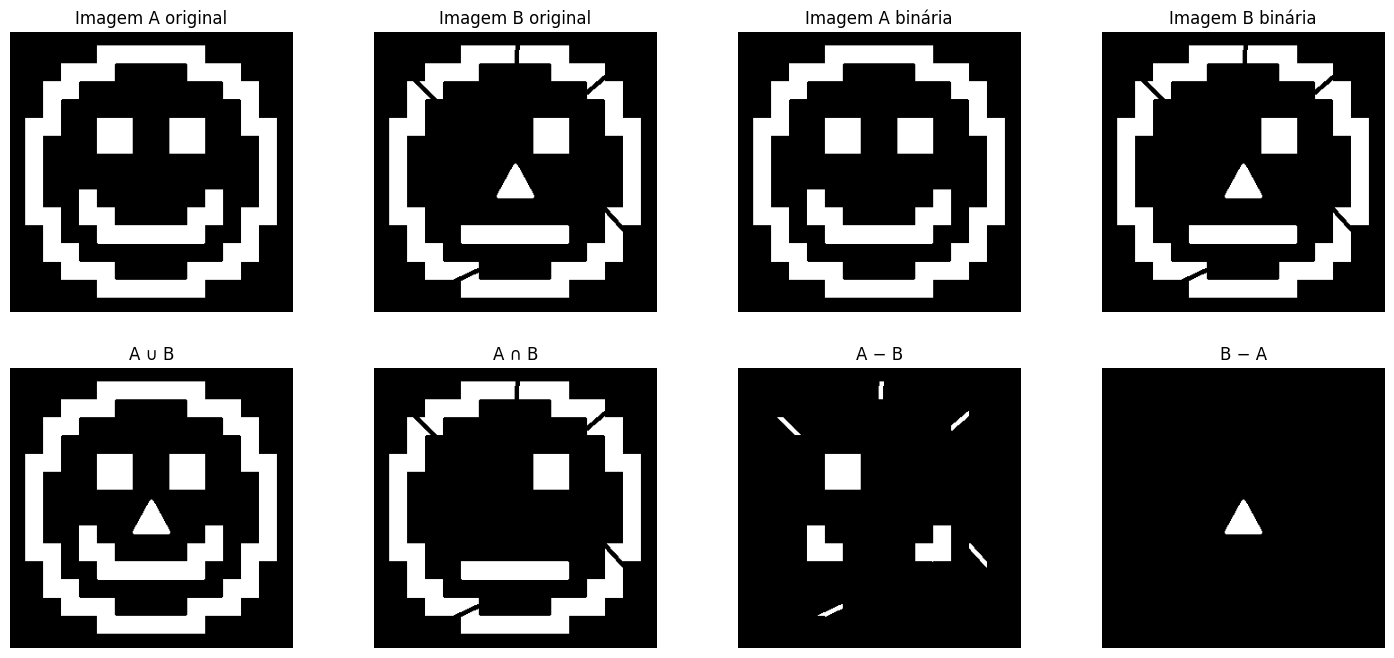

In [58]:
## -- Seu código começa AQUI -- ##

# Carrega as imagens A e B em escala de cinza
img_a = cv2.imread("A.png", cv2.IMREAD_GRAYSCALE)
img_b = cv2.imread("B.png", cv2.IMREAD_GRAYSCALE)

# Converte as imagens para o tipo lógico (True e False)
a_binaria = img_a > 0
b_binaria = img_b > 0

# Operações lógicas entre as imagens binárias

a_uniao_b = np.bitwise_or(a_binaria, b_binaria)            # A ∪ B

a_interseccao_b = np.bitwise_and(a_binaria, b_binaria)     # A ∩ B

complemento_b = np.logical_not(b_binaria)                  # Complemento de B
a_menos_b = np.bitwise_and(a_binaria, complemento_b)       # A - B

complemento_a = np.logical_not(a_binaria)                  # Complemento de A
b_menos_a = np.bitwise_and(b_binaria, complemento_a)       # B - A


# Plota as imagens originais, binarizadas e os resultados
plt.figure(figsize=(18, 8))

plt.subplot(2, 4, 1)
plt.imshow(img_a, cmap="gray")
plt.title("Imagem A original")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(img_b, cmap="gray")
plt.title("Imagem B original")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(a_binaria, cmap="gray")
plt.title("Imagem A binária")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(b_binaria, cmap="gray")
plt.title("Imagem B binária")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(a_uniao_b, cmap="gray")
plt.title("A ∪ B")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(a_interseccao_b, cmap="gray")
plt.title("A ∩ B")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(a_menos_b, cmap="gray")
plt.title("A − B")
plt.axis("off")

plt.subplot(2, 4, 8)
plt.imshow(b_menos_a, cmap="gray")
plt.title("B − A")
plt.axis("off")

plt.show()

## -- Seu código termina AQUI -- ##

## -- COMENTÁRIOS -- ##

# A união A∪B mostra todas as regiões presentes em A ou B.
# A interseção A∩B mostra somente as regiões comuns às duas imagens.
# A diferença A-B mostra as regiões presentes em A que não estão em B.
# A diferença B-A mostra as regiões presentes em B que não estão em A.
# As diferenças A-B e B-A são diferentes porque a operação de diferença
# depende da ordem das imagens.

# OBS: A - B é o mesmo que A interseção com o complemento de B.
# Por isso, foi utilizada a operação AND entre A e o complemento de B.
# Para B - A vale o mesmo.



### 2) Erosão (1,5/10)

A ideia básica de erosão é similar ao que ocorre com a erosão do solo, ela desgasta os limites do objeto em primeiro plano. Então o que isso faz? Ao deslizar o kernel pela imagem (como na convolução 2D - veja a imagem abaixo), um pixel na imagem original (1 ou 0) será considerado 1 apenas se todos os pixels sob o kernel forem 1, caso contrário, ele é "erodido" (reduzido a zero). Então o que acontece é que todos os pixels próximos ao limite serão descartados dependendo do tamanho do kernel. Portanto, a espessura ou o tamanho do objeto em primeiro plano diminui. Esta ferramenta é útil para remover pequenos ruídos brancos, destacar dois objetos conectados  etc. [1].

<center><img src="https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/erosao.gif" width="640" height="298"></center>

<center><caption><b> Figura 2:</b> Animação de uma operação morfológica de erosão.</b></caption></center>
<caption><center> Referência: Peter Corke - <a href="https://www.youtube.com/watch?v=b5lgnNEzGeU">Youtube</a>.</center></caption>

**Exercício:**

A imagem ```coins.jpg``` contém diversas moedas uma ao lado da outra. Suponha que você possua um algoritmo que consiga contar quantas moedas existem na imagem. No entanto, ele só consegue contar se a imagem estiver binarizada e, mais ainda, se não houver conexão de uma moeda com a outra.
1. Leia a imagem ```coins.jpg``` e a transforme para escala de cinza.
2. Utilizando o método de OTSU, faça a binarização desta imagem.
3. Investique um elemento estruturante adequado para realizar a erosão da imagem. Lembre-se: seu objetivo é separar as moedas para que o seu algoritmo consiga realizar o trabalho de contagem.
4. Comente os resultados.


Dicas:

*  A função [cv.erode](https://docs.opencv.org/3.4/d4/d86/group__imgproc__filter.html#gaeb1e0c1033e3f6b891a25d0511362aeb) realiza a operação de erosão.
*  Aqui está o [link](https://docs.opencv.org/3.4.8/d4/d86/group__imgproc__filter.html#gac2db39b56866583a95a5680313c314ad) onde são encontrados os elementos estruturantes pré-definidos disponíveis.
*  A função [cv.getStructuringElement](https://docs.opencv.org/3.4/d4/d86/group__imgproc__filter.html#gac342a1bb6eabf6f55c803b09268e36dc) pode ser usada para gerar um elemento estruturante.
*  Você pode, ainda, criar elementos estruturantes e passar como argumento para a função de erosão.


``` python
cv.erode(myImg, SE, iterations = 1)
cv.getStructuringElement(cv.MORPH_CROSS,(5,5))
```


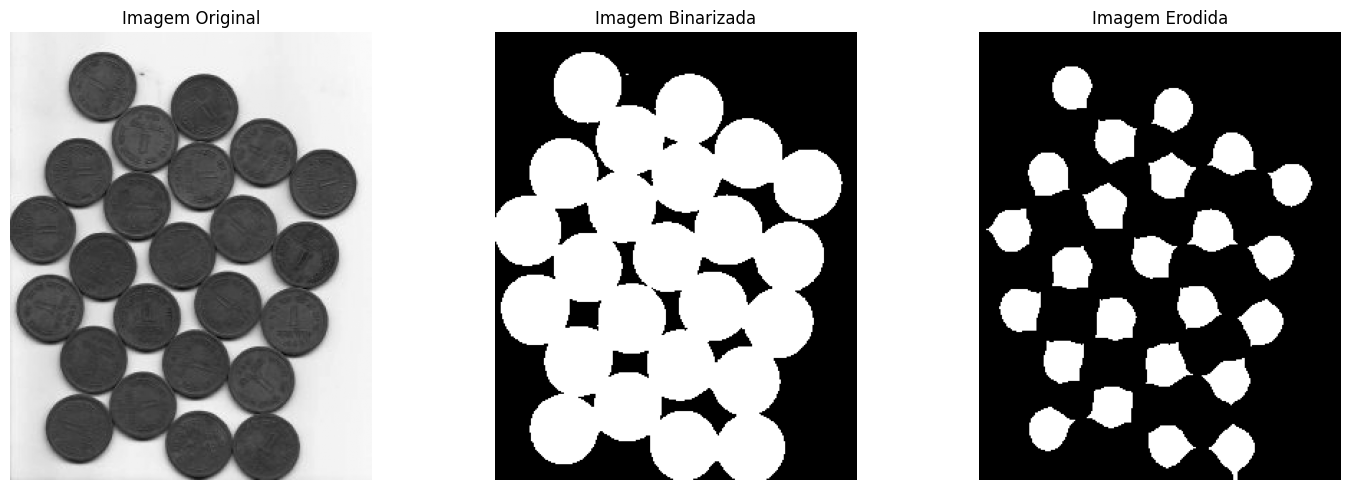

In [108]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## -- Seu código começa AQUI -- ##

# Carrega a imagem em escala de cinza
img = cv2.imread("coins.jpg", cv2.IMREAD_GRAYSCALE)

# Faz a binarização pelo método de Otsu
th_value, bin_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Inverte a imagem para que as moedas fiquem brancas
# e possam ser reduzidas pela erosão
bin_img = cv2.bitwise_not(bin_img)

# Cria um elemento estruturante elíptico 20x20,
# escolhido experimentalmente
elemento_20 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20, 20))

# Faz a erosão da imagem com o elemento estruturante escolhido
erosao_20 = cv2.erode(bin_img, elemento_20, iterations=1)

# Exibe imagem original, binarizada e erodida
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Imagem Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(bin_img, cmap="gray")
plt.title("Imagem Binarizada")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(erosao_20, cmap="gray")
plt.title("Imagem Erodida")
plt.axis("off")

plt.tight_layout()
plt.show()

## -- Seu código termina AQUI -- ##

## -- COMENTÁRIOS -- ##

# Foi escolhido um elemento estruturante elíptico, pois as moedas
# possuem formato aproximadamente circular.

# O tamanho 20x20 foi escolhido experimentalmente,
# pois foi o menor tamanho que conseguiu separar todas as moedas conectadas.
# Após testar diferentes tamanhos, verificou-se que 19x19 ainda
# mantinha algumas moedas conectadas.

# Apesar da redução no tamanho das moedas causada pela erosão,
# o resultado permite que cada moeda seja identificada
# individualmente para a contagem.


### 3) Dilatação (1.5/10)

Esta operação é exatamente o oposto da erosão. Aqui, um pixel se torna '1' se pelo menos um pixel sob o kernel for '1'. Portanto, aumenta a região branca na imagem ou o tamanho do objeto em primeiro plano (veja a imagem abaixo). Normalmente, em casos como remoção de ruído, a erosão é seguida de dilatação, porque a erosão remove os ruídos brancos, mas também diminui o objeto. Em seguida, é aplicada a dilatação para que o objeto retorne ao seu tamanho original, agora sem ruído. Também é útil para unir partes quebradas de um objeto. [1].

<center><img src="https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/dilatacao.gif" width="640" height="298"></center>

<center><caption><b> Figura 3: </b> Animação de uma operação morfológica de dilatação.</b></caption></center>
<caption><center> Referência: Peter Corke - <a href="https://www.youtube.com/watch?v=3IJ8RFtlDLY">Youtube</a>.</center></caption>


**Exercício:**

1. Carregue a imagem ```texto.png``` e faça a operação de dilatação utilizando o seguinte elemento estruturante (SE):

\begin{equation}
SE =
\begin{bmatrix}
1 & 0 & 1\\
0 & 1 & 0\\
1 & 0 & 1
\end{bmatrix}
\end{equation}

Mostre a imagem original, o elemento estruturante e o resultado da dilatação.

2. Gere os seguintes elementos estruturantes para dilatar a imagem. Mostre estes elementos estruturantes em *subplots*.

  *   SE1: Elipse de tamanho 8;
  *   SE2: Retângulo de tamanho 6;
  *   SE3: Cruz de tamanho 10.

3. Mostre as imagens resultantes da dilatação com os elementos estruturantes do ítem 2. **Comente os resultados encontrados.**

4. Faça a erosão da imagem resultante da dilatação com o elemento estruturante SE1, agora com um elemento estruturante em forma de retângulo de tamanho 5.
5. Subtraia a imagem original doo resultado do item 4.** Comente os resultados.**

Dicas:

*  A função [cv.dilate](https://docs.opencv.org/3.4/d4/d86/group__imgproc__filter.html#ga4ff0f3318642c4f469d0e11f242f3b6c) realiza a operação de dilatação.
Aqui está o [link](https://docs.opencv.org/3.4.8/d4/d86/group__imgproc__filter.html#gac2db39b56866583a95a5680313c314ad) onde são encontrados os elementos estruturantes pré-definidos disponíveis.
*  A função [cv.getStructuringElement](https://docs.opencv.org/3.4.20/d4/d86/group__imgproc__filter.html#gac342a1bb6eabf6f55c803b09268e36dc) gera os elementos estruturantes pré-definidos.  
*  Você pode, ainda, criar elementos estruturantes e passar como argumento para a função de dilatação.

``` python
SE = cv.getStructuringElement(cv.MORPH_RECT,(Size,Size))
cv.dilate(myImg, SE, iterations = 1)
```

In [ ]:
## -- Seu código começa AQUI -- ##

## -- Seu código termina AQUI -- ##

## -- COMENTÁRIOS -- ##


### 4) Abertura e Fechamento (1.5/10)


Abertura é o nome dado à operação de erosão seguida de dilatação. É útil na remoção de ruído, como no exemplo da figura abaixo.


<center><img src="https://docs.opencv.org/3.4.8/opening.png" width="224" height="150"></center>

<center><caption><b> Figura 4: </b> Operação morfológica de abertura.</b></caption></center>
<caption><center> Referência: OpenCV - <a href="https://docs.opencv.org/3.4.8/d9/d61/tutorial_py_morphological_ops.html">Morphological Transformations</a>.</center></caption>

O fechamento é o processo inverso da abertura, ou seja, dilatação seguida de erosão. É útil para fechar pequenos orifícios dentro dos objetos em primeiro plano ou pequenos pontos pretos no objeto.

<center><img src="https://docs.opencv.org/3.4.8/closing.png" width="224" height="150"></center>

<center><caption><b> Figura 5: </b> Operação morfológica de fechamento.</b></caption></center>
<caption><center> Referência: OpenCV - <a href="https://docs.opencv.org/3.4.8/d9/d61/tutorial_py_morphological_ops.html">Morphological Transformations</a>.</center></caption>




**Exercício:**

1. Aplicar os seguintes filtros morfológicos na imagem ```shapes.png```:

  *   Abertura, utilizando um elemento estruturante quadrado de largura 9;
  *   Fechamento, com o mesmo elemento estruturante anterior.

2. **Desafio!** Utilizando os conceitos praticados até agora:
  * Proponha uma sequêcia de operações de modo que, a partir da imagem original ```shapes.png``` , o resultado seja uma imagem final conforme a imagem abaixo.
<center><img src="https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/shapes_resultado.png" width="224" height="150"></center>
<center><caption><b> Figura 6: </b> Resultado da sequência de operações aplicadas à imagem shapes.png</b></caption></center>


  * Você pode usar tanto operações lógicas (conforme Exercício 1), quanto operações morfológicas.
  * A imagem resultante foi disponibilizada (```shapes_resultado.png```). Seu formato é ```uint8``` e seu range vai de (0 a 255). Você deve usá-la somente para verificação do seu resultado. Ou seja, ao final, a imagem que você obtiver deve ser igual à imagem ```shapes_resultado.png```. Isso pode ser confirmado fazendo a subtração das imagens. O resultado da subtração deve ser uma imagem que tenha todos os seus elementos iguais a 0 (zero).
  * **Mostre em subplots as figuras resultantes das etapas de sua proposta. Coloque título em cada uma delas para melhor organização.**


**Dicas:**
*  A função [cv.morphologyEx](https://docs.opencv.org/3.4.8/d4/d86/group__imgproc__filter.html#ga67493776e3ad1a3df63883829375201f) realiza diversas operações de morfologia. Os diferentes tipos de operações podem ser consultados [aqui](https://docs.opencv.org/3.4.8/d9/d61/tutorial_py_morphological_ops.html).


``` python
cv.morphologyEx(myImg, cv.MORPH_OPEN , SE)
cv.morphologyEx(myImg, cv.MORPH_CLOSE, SE)
```

In [ ]:
## -- Seu código começa AQUI -- ##



## -- Seu código termina AQUI -- ##

## -- COMENTÁRIOS -- ##



### 5) Hit or Miss (1.5/10)

A transformação Hit-or-Miss é útil para encontrar padrões em imagens binárias. Em particular, ela encontra aqueles pixels cuja vizinhança corresponde à forma de um primeiro elemento estruturante (B1) enquanto não corresponde à forma de um segundo elemento estruturante (B2), ao mesmo tempo.
Uma outra forma de interpretar é que você deseja que os elementos "brancos" sejam correspondentes a B1, e que os elementos "pretos" (background) seja correspondente a B2.
Matematicamente, a operação aplicada a uma imagem A pode ser expressa da seguinte forma:

\begin{equation}
A⊛B = (A⊖B_1)∩(A^C⊖B_2)
\end{equation}

Portanto, a operação Hit-or-Miss pode ser feita em 3 passos:

1. Erosão da imagem A com o elemento estruturante B1.
2. Erosão do complemento da imagem A com o elemento estruturante B2.
3. AND (lógico) dos resultados de 1 e 2.

Abaixo, veja um exemplo de elementos estruturantes, B1 e B2.
<center><img src="https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/hit-miss_exemplos_SEelements.png" width="224" height="150"></center>
<center><caption><b> Figura 7: </b> Elementos estruturais B1 e B2.</b></caption></center>

Nesse caso, queremos achar um elemento cujos pixels norte, sul, leste e oeste (B1) sejam "brancos" e  cujo pixel central seja preto (pertencente ao background). Aplicando estes elementos por meio  da transformada hit-or-miss a uma imagem de entrada:
<center><img src="https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/hit-miss_exemplos_inputimage.png" width="250" height="250"></center>
<center><caption><b> Figura 8: </b> Imagem de entrada.</b></caption></center>

<center><img src="https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/hit-miss_exemplos_outputimage.png" width="250" height="250"></center>
<center><caption><b> Figura 9: </b> Imagem de saída, pós aplicação da transformação hit-or-miss.</b></caption></center>



Veja que, quando as condições mencionadas são satisfeitas, o resultado é uma imagem que indica o pixel central do elemento encontrado.


**5.1)** No código abaixo, foi fornecida uma matriz, representando uma imagem. Você deseja encontrar **somente** a letra T da parte inferior direita. Utilizando os conceitos de hit-or-miss, proponha a utilização de 2 elementos estruturantes e aplique na imagem. Mostre os resultados e comente.


**5.2)** A imagem ```shapes.png```possui um quadrado branco, localizado na parte direita da imagem. Você deseja encontrar **somente** este quadrado. (O quadrado possui tamanho 7x7). Utilizando os conceitos de hit-or-miss, proponha a utilização de 2 elementos estruturantes e aplique na imagem. Mostre os resultados e comente.

**Dica:** Lembre-se de que você tem "considerar" o background arredor do seu quadrado.



In [ ]:
# 5.1
imagem = np.array((
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 255, 255, 255, 0, 0, 0, 255],
    [0, 0, 255, 255, 0, 0, 0, 0],
    [0, 0, 255, 255, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 255, 255, 0, 0, 255, 255, 255],
    [0,255, 0, 0, 0, 0, 255, 0],
    [0, 255, 0, 0, 0, 0, 255, 0]), dtype="uint8")

## -- Seu código começa AQUI -- ##



## -- Seu código termina AQUI -- ##

## -- COMENTÁRIOS -- ##

In [ ]:
#5.2
## -- Seu código começa AQUI -- ##



## -- Seu código termina AQUI -- ##

## -- COMENTÁRIOS -- ##

### 6) Aplicação (2.0/10)

Você foi contratado por uma empresa de *e-commerce* para facilitar a vida de seus clientes ao inserir as informações do cartão de crédito no momento da compra. Você deve desenvolver um aplicativo de celular que irá utilizar a câmera e assim o usuário apontará para seu cartão e você deverá fazer a leitura dos números por meio de técnicas de visão computacional.

<center><img src="https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/raw/main/imagens/pratica_02/card1.jpg" width="224" height="150"></center>

<center><caption><b> Figura 10: </b> Cartão de crédito.</b></caption></center>

Para isto, vamos utilizar técnicas para o Reconhecimento Ótico de Caracteres (*Optical Character Recognition* - [OCR](https://en.wikipedia.org/wiki/Optical_character_recognition)). Perceba que este método utiliza técnicas convencionais de visão computacional, tais como: operações morfológicas, métodos de segmentação e classificação por comparação de templates. Naturalmente, o método tem suas limitações e você observará isso.

**Exercício:**

1. Faça a leitura da imagem ```card1.jpg```, converta-a para o tamanho $altura:189 \times largura:300$. Em seguida converta-a para nível de cinza.

2. Crie dois elementos estruturantes que iremos utilizar:

  *   Retângulo de tamanho 9x3;
  *   Quadrado de tamanho 5x5.

3. Após a operação de segmentação por Otsu, observe que os números foram segmentados corretamente. No entanto, diversas outras coisas também foram. Para que possamos identificar de maneira correta os 4 grupos de 4 números, utilize a operação morfológica de fechamento para juntar o grupo de 4 números em um só, criando assim uma máscara:

   *   Aplique uma operação de **fechamento** com o SE retangular na imagem ```thresh```;
   *   Aplique uma operação de **fechamento** com o SE quadrado na imagem resultante da operação anterior. Atribua esse resultado a uma variável chamada ```mask```.

5. Por fim, mostre o resultado gerado pela função ```ocr.find_card_numbers```.

4. Três diferentes imagens de cartões de créditos são fornecidas. Teste-as e conclua algo sobre o resultado delas. Sinta-se à vontade para buscar outras imagens na internet e testar os resultados.

Referência:

*   Credit Card OCR with OpenCV and Python - [Pyimagesearch](https://www.pyimagesearch.com/2017/07/17/credit-card-ocr-with-opencv-and-python/).


**Dicas:**

*  **Os nomes das variáveis já estão escritas no código. Utilize essa mesma nomenclatura pois algumas funções já escritas dependem destas variáveis. Escreva seu código os estão as palavras ```None```.**

*  **Fique atento às indicações onde seu código deve começar e terminar. Não altere as funções fora das indicações.**

*  Caso você tenha interesse em saber como está sendo feita a classificação, visite o blog mencionado nas referências e também o código ```ocr_functions.py```.

In [ ]:
# O nome das diversas imagens:
# | "card2.png" | "card3.png" | "card4.jpg" |

from ocr_functions import ocr_Helper

# Função que nos auxiliará a classificar os dígitos
ocr = ocr_Helper()

## -- Seu código começa AQUI -- ##

## -- Seu código termina AQUI -- ##

#VOCÊ PODE TROCAR O NOME DA VARIÁVEL image_rgb_resize NA LINHA ABAIXO.
#PARA QUE SEJA IGUAL À QUE COLOCOU NA SUA PARTE DO CÓDIGO ACIMA.

image_rgb = image_rgb_resize


# Operação morfológica que resulta na diferença entre uma abertura e a
# imagem original.

#VOCÊ PODE TROCAR O NOME DA VARIÁVEL image_gray NA LINHA ABAIXO.
#PARA QUE SEJA IGUAL À QUE COLOCOU NA SUA PARTE DO CÓDIGO ACIMA.

tophat = cv.morphologyEx(image_gray, cv.MORPH_TOPHAT, kernel_rect)

plt.figure(figsize=(10,5))
plt.imshow(tophat,cmap='gray')
plt.show()

# Segmentação pelo método de Otsu
thresh = cv.threshold(tophat, 0, 255,cv.THRESH_BINARY | cv.THRESH_OTSU)[1]
plt.figure(figsize=(10,5))
plt.imshow(thresh,cmap='gray')
plt.show()

## -- Seu código começa AQUI -- ##

## -- Seu código termina AQUI -- ##


# O identificador possui algumas condições para ser eficiente, como a fonte dos números do cartão não corresponderem à OCR, causando erro na identificação.
# Também pode confundir outras informações do cartão com o número em si (caso em que as fontes são próximas).


image_out = ocr.find_card_numbers(image_rgb, image_gray, mask)


## -- Seu código começa AQUI -- ##
# Mostrar a imagem "image_out" aqui
## -- Seu código termina AQUI -- ##